Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

══════════════════════════════════════════════════════════
  SECTION 1 — LOAD DATA
══════════════════════════════════════════════════════════
[✓] Loaded from Drive — 440,833 rows × 12 columns

── Sample ──────────────────────────────


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0



── Dtypes ──────────────────────────────
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64

── Missing Values ──────────────────────
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1

── Target Distribution ─────────────────
Churn
0.0    190833
1.0    249999
  Overall Churn Rate: 56.7%

══════════════════════════════════════════════════════════
  SECTION 2 — CLEANING
══════════════════════════════════════════════════════════
[✓] Dropped: ['CustomerID']
[✓] Imputed 11 mis

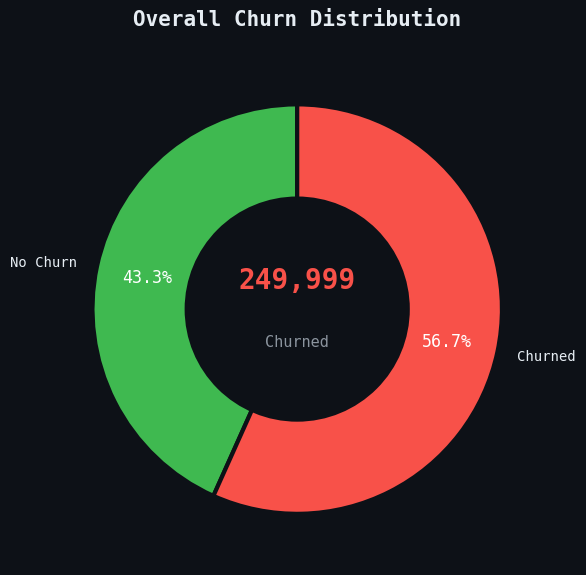

    [✓] plot1_churn_distribution.png


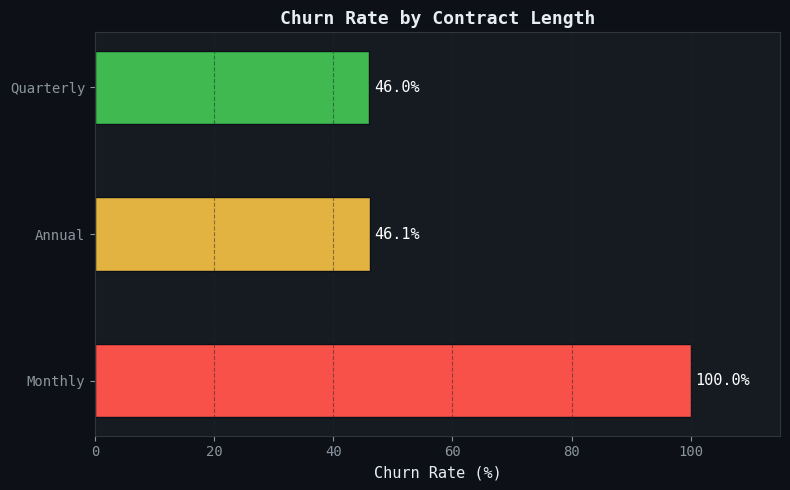

    [✓] plot2_contract_churn.png


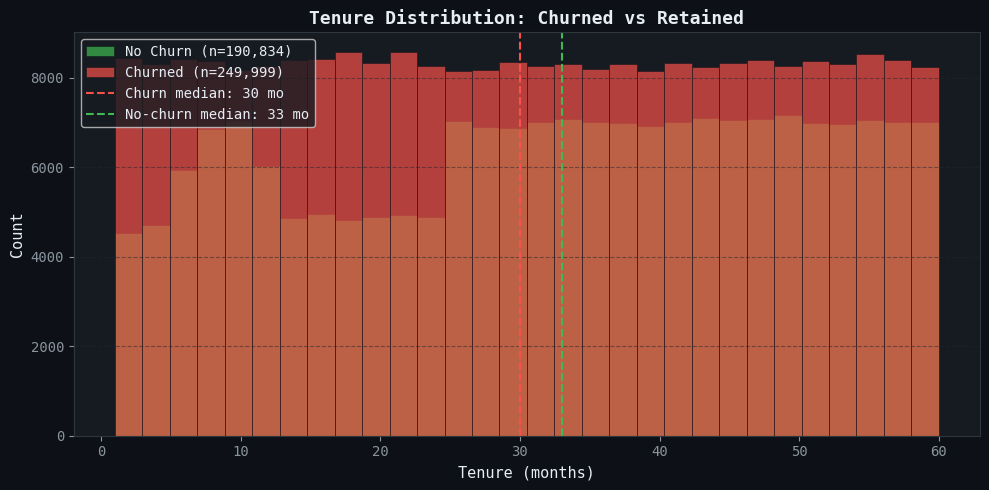

    [✓] plot3_tenure.png


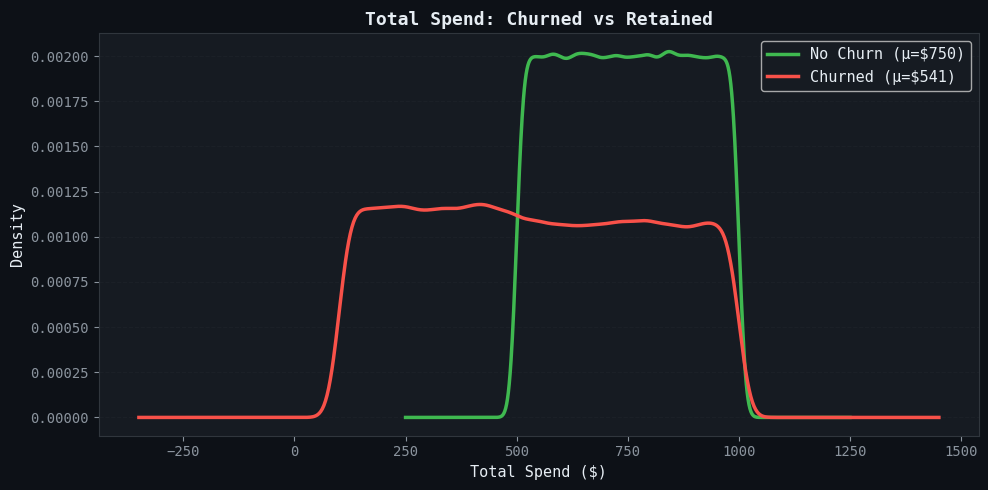

    [✓] plot4_total_spend.png


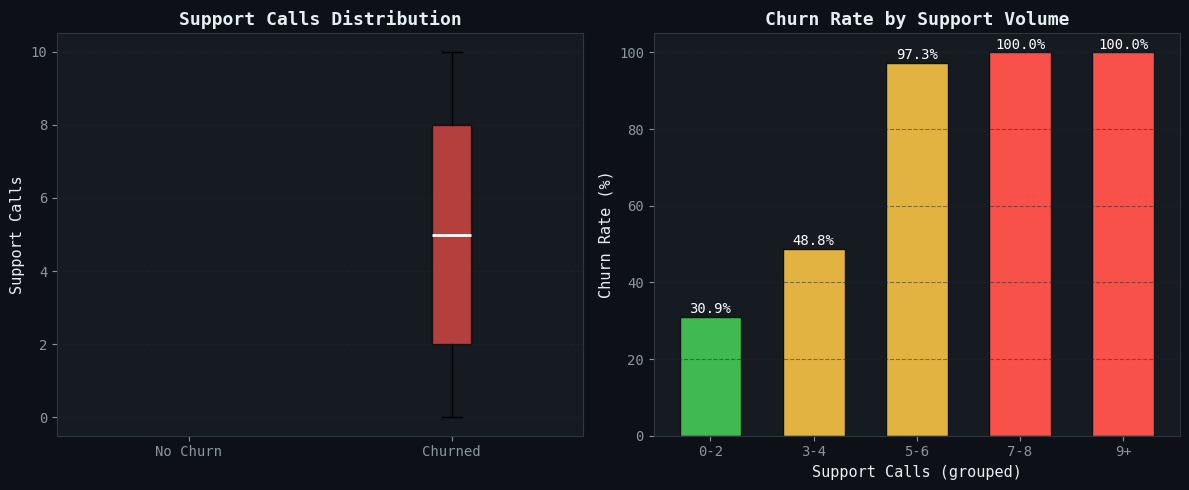

    [✓] plot5_support_calls.png


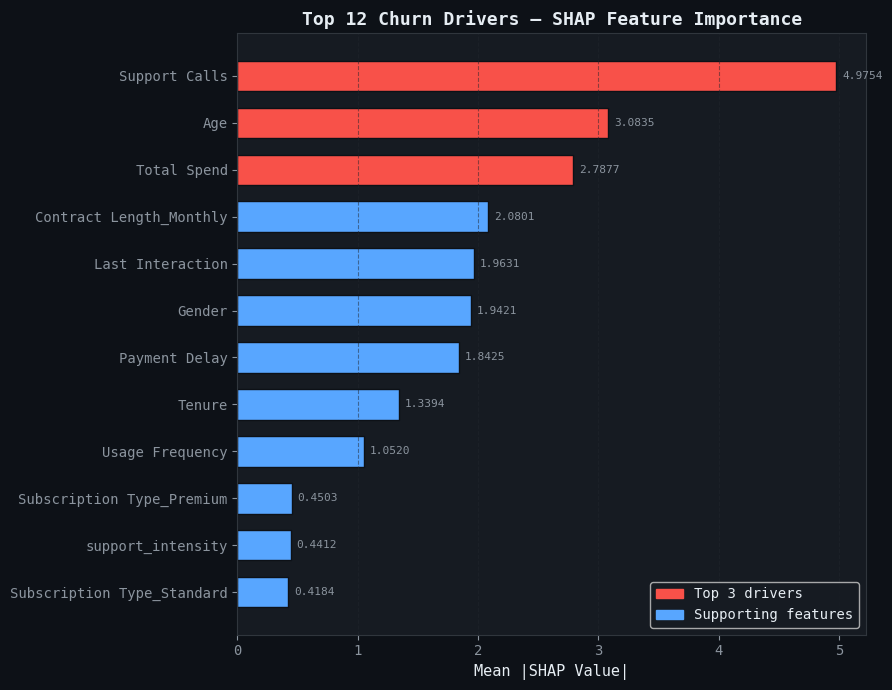

    [✓] plot6_shap_importance.png


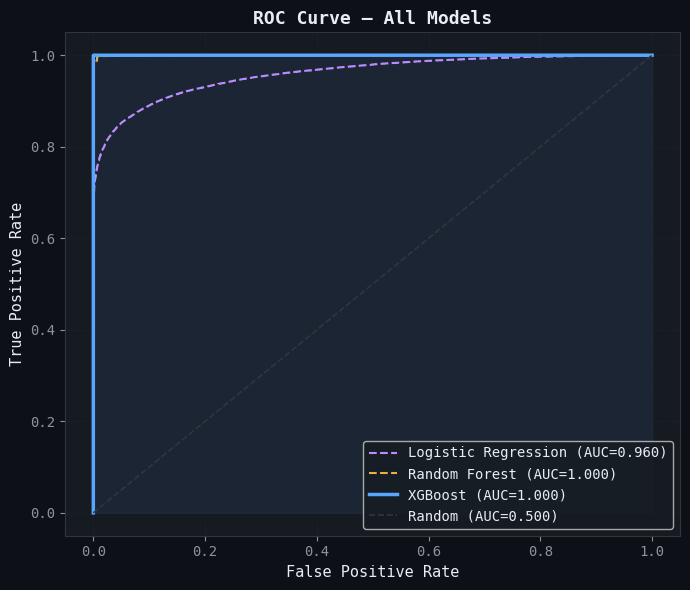

    [✓] plot7_roc_curve.png


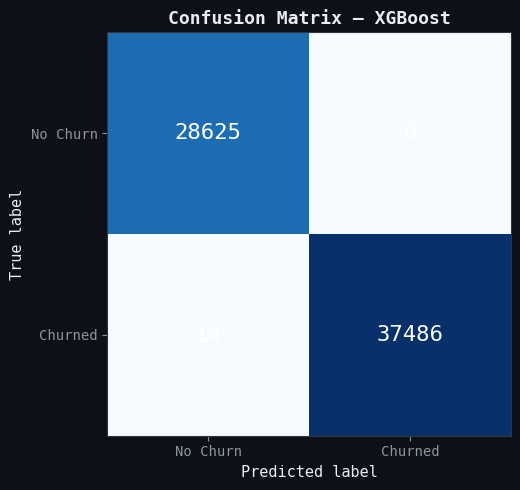

    [✓] plot8_confusion_matrix.png


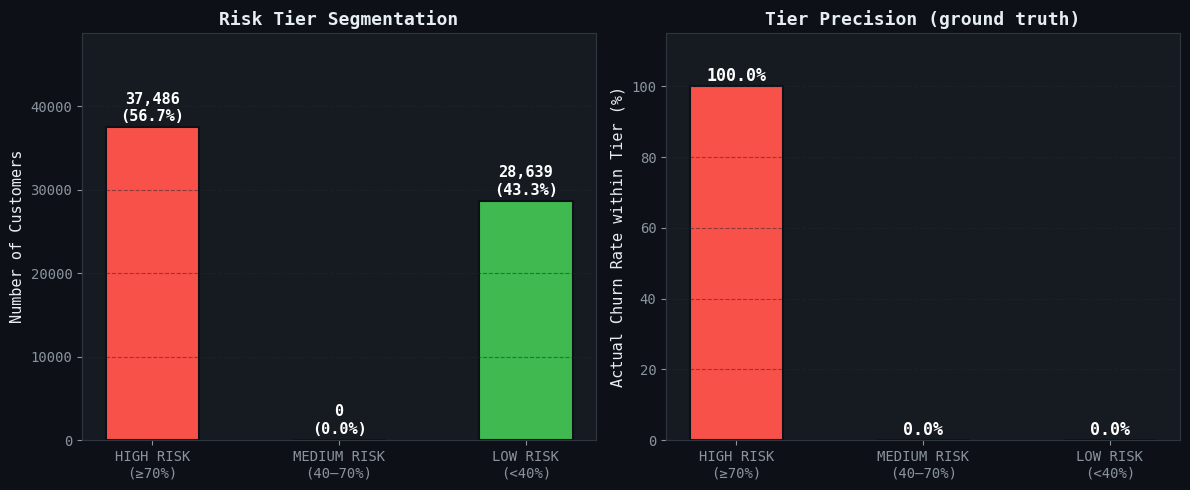

    [✓] plot9_risk_tiers.png


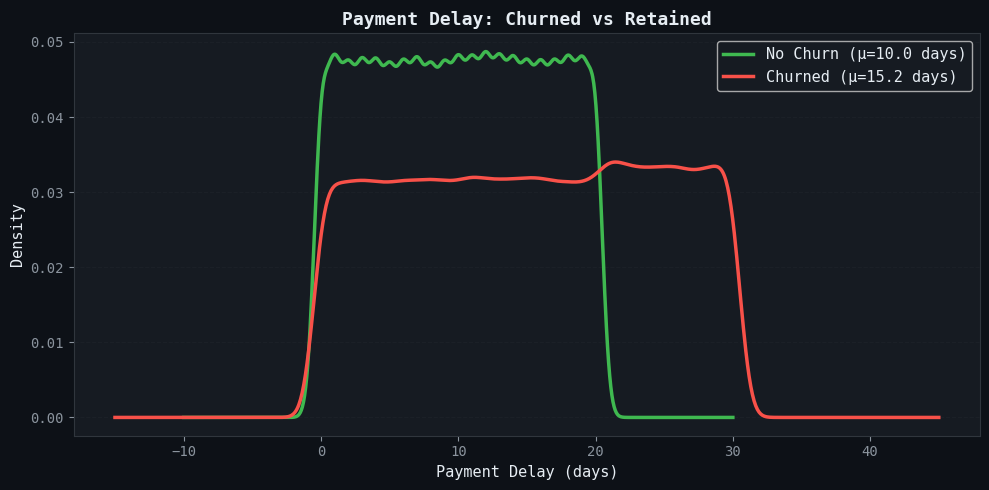

    [✓] plot10_payment_delay.png


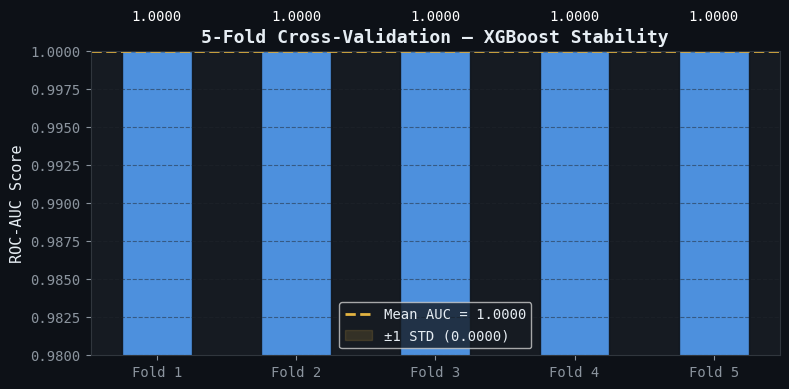

    [✓] plot11_cross_validation.png

══════════════════════════════════════════════════════════
  SECTION 8 — EXECUTIVE SUMMARY
══════════════════════════════════════════════════════════

  Best Model       : XGBoost
  Accuracy         : 99.98%
  F1-Score         : 0.9998
  ROC-AUC          : 1.0000
  CV ROC-AUC       : 1.0000 ± 0.0000

  High-Risk Customers Identified : 37,486
  Estimated Revenue at Risk       : $23,676,766
  Potential Recovery (33%)        : $7,813,333

  Top 3 Churn Drivers (SHAP):
    1. Support Calls
    2. Age
    3. Total Spend

✅ Full pipeline complete.
   Saved: xgb_churn_model.pkl | scaler.pkl | test_predictions.csv
   Plots: plot1 through plot11 in /content/

   Next → Run Pipeline 3 (Groq Retention Advisor) for the live demo.


In [ ]:
!pip install shap xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import xgboost as xgb

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# GLOBAL PLOT STYLE
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "#0d1117",
    "axes.facecolor"   : "#161b22",
    "axes.edgecolor"   : "#30363d",
    "axes.labelcolor"  : "#e6edf3",
    "axes.titlecolor"  : "#e6edf3",
    "xtick.color"      : "#8b949e",
    "ytick.color"      : "#8b949e",
    "text.color"       : "#e6edf3",
    "grid.color"       : "#21262d",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.family"      : "monospace",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

GREEN  = "#3fb950"
RED    = "#f85149"
BLUE   = "#58a6ff"
ORANGE = "#e3b341"
PURPLE = "#bc8cff"

def _save_show(fig, filename, title=None):
    if title:
        fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"    [✓] {filename}")

def _section(title):
    bar = "═" * 58
    print(f"\n{bar}\n  {title}\n{bar}")

# ══════════════════════════════════════════════════════════
#  SECTION 1 — LOAD DATA
# ══════════════════════════════════════════════════════════
_section("SECTION 1 — LOAD DATA")

DATA_PATH = "/content/drive/MyDrive/customer_churn_dataset-training-master.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"[✓] Loaded from Drive — {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset not found at:\n  {DATA_PATH}\n"
        "Update DATA_PATH to your actual file location."
    )

# Keep a raw copy — used by visualization section
df_raw = df.copy()

print("\n── Sample ──────────────────────────────")
display(df.head(3))

print("\n── Dtypes ──────────────────────────────")
print(df.dtypes.to_string())

print("\n── Missing Values ──────────────────────")
missing = df.isnull().sum()
missing = missing[missing > 0]
print("  None ✓" if missing.empty else missing.to_string())

print("\n── Target Distribution ─────────────────")
churn_counts = df["Churn"].value_counts().sort_index()
print(churn_counts.to_string())
print(f"  Overall Churn Rate: {df['Churn'].mean():.1%}")

# ══════════════════════════════════════════════════════════
#  SECTION 2 — CLEANING
# ══════════════════════════════════════════════════════════
_section("SECTION 2 — CLEANING")

# Drop ID column — zero predictive value
DROP_COLS = ["CustomerID"]
dropped = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=dropped, inplace=True)
print(f"[✓] Dropped: {dropped}")

# Coerce any string columns that should be numeric
for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col], errors="ignore")
    if converted.dtype != object:
        df[col] = converted
        print(f"  [!] Auto-converted '{col}' to numeric")

# Impute missing values
missing_before = df.isnull().sum().sum()
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype in ["float64", "int64"]:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)
missing_after = df.isnull().sum().sum()
print(f"[✓] Imputed {missing_before} missing values → {missing_after} remaining")

# Churn must be integer (was float 1.0/0.0)
df["Churn"] = df["Churn"].astype(int)
print(f"[✓] Churn cast to int")

# ══════════════════════════════════════════════════════════
#  SECTION 3 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════
_section("SECTION 3 — FEATURE ENGINEERING")

# High spend + low usage → dissatisfied customer
df["spend_per_usage"] = df["Total Spend"] / (df["Usage Frequency"] + 1)

# Support calls normalized by tenure → recent complainer signal
df["support_intensity"] = df["Support Calls"] / (df["Tenure"] + 1)

# Payment delay risk tier (ordinal)
df["delay_risk"] = pd.cut(
    df["Payment Delay"],
    bins=[0, 5, 15, 25, 100],
    labels=[0, 1, 2, 3]
).fillna(0).astype(int)

print("[✓] Engineered 3 new features:")
print("    spend_per_usage   — Total Spend / (Usage Frequency + 1)")
print("    support_intensity — Support Calls / (Tenure + 1)")
print("    delay_risk        — Payment Delay bucketed into 4 ordinal levels")

# ══════════════════════════════════════════════════════════
#  SECTION 4 — ENCODING
# ══════════════════════════════════════════════════════════
_section("SECTION 4 — ENCODING")

BINARY_COLS    = []
MULTI_CAT_COLS = []
NUM_COLS       = []

for col in df.columns:
    if col == "Churn":
        continue
    if df[col].dtype == object:
        if df[col].nunique() == 2:
            BINARY_COLS.append(col)
        else:
            MULTI_CAT_COLS.append(col)
    else:
        NUM_COLS.append(col)

print(f"Binary categorical : {BINARY_COLS}")
print(f"Multi categorical  : {MULTI_CAT_COLS}")
print(f"Numerical          : {NUM_COLS}")

# Binary encode
BINARY_MAP = {"Male": 1, "Female": 0, "Yes": 1, "No": 0}
for col in BINARY_COLS:
    unique_vals = set(df[col].dropna().unique())
    if unique_vals.issubset(set(BINARY_MAP.keys())):
        df[col] = df[col].map(BINARY_MAP)
    else:
        df[col] = df[col].astype("category").cat.codes
    print(f"  [✓] '{col}' → 0/1")

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=MULTI_CAT_COLS, drop_first=True)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
print(f"[✓] One-hot encoded: {MULTI_CAT_COLS}")
print(f"[✓] Final shape after encoding: {df.shape}")

# ══════════════════════════════════════════════════════════
#  SECTION 5 — SPLIT & SCALE
# ══════════════════════════════════════════════════════════
_section("SECTION 5 — SPLIT & SCALE")

X = df.drop("Churn", axis=1)
y = df["Churn"]
FEATURE_NAMES = list(X.columns)

# 3-way split: 70% train | 15% val (early stopping) | 15% test (final eval)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:,} rows | Churn rate: {y_train.mean():.1%}")
print(f"Val   : {X_val.shape[0]:,} rows  | Churn rate: {y_val.mean():.1%}")
print(f"Test  : {X_test.shape[0]:,} rows | Churn rate: {y_test.mean():.1%}")

# Scale numerical features — fit ONLY on train (no leakage)
scaler = StandardScaler()
eng_features   = ["spend_per_usage", "support_intensity", "delay_risk"]
num_cols_final = [c for c in NUM_COLS + eng_features if c in X_train.columns]

X_train[num_cols_final] = scaler.fit_transform(X_train[num_cols_final])
X_val[num_cols_final]   = scaler.transform(X_val[num_cols_final])
X_test[num_cols_final]  = scaler.transform(X_test[num_cols_final])

print(f"\n[✓] Scaled {len(num_cols_final)} numerical columns (fit on train only)")

# Class imbalance weight for XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"[✓] Class ratio — Neg: {neg:,} | Pos: {pos:,} | scale_pos_weight: {spw:.2f}")

# ══════════════════════════════════════════════════════════
#  SECTION 6 — TRAIN 3 MODELS
# ══════════════════════════════════════════════════════════
_section("SECTION 6 — TRAINING MODELS")

results = {}

# ── Logistic Regression (baseline) ────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
results["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, lr_pred),
    "f1"      : f1_score(y_test, lr_pred),
    "roc_auc" : roc_auc_score(y_test, lr_prob),
    "pred"    : lr_pred,
    "prob"    : lr_prob,
}
print(f"  Done. ROC-AUC: {results['Logistic Regression']['roc_auc']:.4f}")

# ── Random Forest ──────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
results["Random Forest"] = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "f1"      : f1_score(y_test, rf_pred),
    "roc_auc" : roc_auc_score(y_test, rf_prob),
    "pred"    : rf_pred,
    "prob"    : rf_prob,
}
print(f"  Done. ROC-AUC: {results['Random Forest']['roc_auc']:.4f}")

# ── XGBoost with early stopping (main model) ──────────────
print("Training XGBoost (with early stopping)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="logloss",
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],   # val set — NOT test set
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
results["XGBoost"] = {
    "accuracy": accuracy_score(y_test, xgb_pred),
    "f1"      : f1_score(y_test, xgb_pred),
    "roc_auc" : roc_auc_score(y_test, xgb_prob),
    "pred"    : xgb_pred,
    "prob"    : xgb_prob,
}
print(f"  Done. Best iteration: {xgb_model.best_iteration} trees")
print(f"  ROC-AUC: {results['XGBoost']['roc_auc']:.4f}")

# ── Model Comparison Table ─────────────────────────────────
print(f"\n{'═'*54}")
print(f"  {'Model':<22} {'Accuracy':>9} {'F1':>8} {'ROC-AUC':>9}")
print(f"{'─'*54}")
for name, r in results.items():
    marker = "  ◀ BEST" if name == "XGBoost" else ""
    print(f"  {name:<22} {r['accuracy']:>9.4f} {r['f1']:>8.4f} {r['roc_auc']:>9.4f}{marker}")
print(f"{'═'*54}")

print(f"\n── XGBoost Classification Report ───────")
print(classification_report(y_test, xgb_pred, target_names=["No Churn", "Churn"]))

# ── 5-Fold Cross Validation ────────────────────────────────
print("Running 5-fold cross-validation (ROC-AUC)...")
xgb_cv = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration,
    learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"\n── 5-Fold CV ROC-AUC (XGBoost) ────────")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"  Mean : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Risk Tier Segmentation ─────────────────────────────────
def assign_risk_tier(prob):
    if prob >= 0.70:   return "🔴 HIGH RISK"
    elif prob >= 0.40: return "🟡 MEDIUM RISK"
    else:              return "🟢 LOW RISK"

results_df = pd.DataFrame({
    "churn_probability" : xgb_prob,
    "predicted_churn"   : xgb_pred,
    "actual_churn"      : y_test.values,
})
results_df["risk_tier"] = results_df["churn_probability"].apply(assign_risk_tier)

print("\n── Risk Tier Distribution ──────────────")
tier_counts = results_df["risk_tier"].value_counts()
for tier, cnt in tier_counts.items():
    print(f"  {tier:<18} : {cnt:>5,} ({cnt/len(results_df):.1%})")

# ── SHAP Values ────────────────────────────────────────────
print("\nComputing SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test)
shap_df = pd.DataFrame({
    "Feature"    : FEATURE_NAMES,
    "Mean|SHAP|" : np.abs(shap_vals).mean(axis=0)
}).sort_values("Mean|SHAP|", ascending=False).reset_index(drop=True)

print("\n── Top 10 Features (SHAP) ──────────────")
print(shap_df.head(10).to_string(index=False))

# ── Save Artifacts ─────────────────────────────────────────
joblib.dump(xgb_model,     "xgb_churn_model.pkl")
joblib.dump(scaler,        "scaler.pkl")
joblib.dump(FEATURE_NAMES, "feature_columns.pkl")
results_df.to_csv("test_predictions.csv", index=False)
df_raw.to_csv("df_raw.csv", index=False)
shap_df.to_csv("shap_importance.csv", index=False)
print("\n[✓] Artifacts saved to /content/")

# ══════════════════════════════════════════════════════════
#  SECTION 7 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════
_section("SECTION 7 — VISUALIZATIONS")

print("Generating plots...\n")

# Fill NaN values in 'Churn' column of df_raw before converting to int
df_raw["Churn"].fillna(0, inplace=True)

# ── Plot 1: Churn Distribution Donut ──────────────────────
churn_vals = df_raw["Churn"].astype(int)
sizes  = [int((churn_vals == 0).sum()), int((churn_vals == 1).sum())]
labels = ["No Churn", "Churned"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    sizes, labels=labels, colors=[GREEN, RED],
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops={"linewidth": 3, "edgecolor": "#0d1117"}
)
ax.add_patch(plt.Circle((0, 0), 0.55, fc="#0d1117"))
ax.text(0, 0.10, f"{sizes[1]:,}", ha="center", fontsize=20,
        color=RED, fontweight="bold")
ax.text(0, -0.18, "Churned", ha="center", fontsize=11, color="#8b949e")
for t in autotexts:
    t.set_fontsize(12); t.set_color("white")
ax.set_title("Overall Churn Distribution", pad=20, fontsize=15, fontweight="bold")
_save_show(fig, "plot1_churn_distribution.png")

# ── Plot 2: Churn Rate by Contract Length ─────────────────
if "Contract Length" in df_raw.columns:
    cc = (df_raw.groupby("Contract Length")["Churn"]
          .apply(lambda x: x.astype(int).mean())
          .reset_index()
          .rename(columns={"Churn": "ChurnRate"})
          .sort_values("ChurnRate", ascending=False))
    cc["ChurnRate"] *= 100

    fig, ax = plt.subplots(figsize=(8, 5))
    bar_colors = [RED, ORANGE, GREEN][:len(cc)]
    bars = ax.barh(cc["Contract Length"], cc["ChurnRate"],
                   color=bar_colors, height=0.5, edgecolor="#0d1117")
    for bar, val in zip(bars, cc["ChurnRate"]):
        ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=11, color="white")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_title("Churn Rate by Contract Length", fontweight="bold")
    ax.set_xlim(0, cc["ChurnRate"].max() + 15)
    ax.grid(axis="x")
    _save_show(fig, "plot2_contract_churn.png")

# ── Plot 3: Tenure Distribution ───────────────────────────
if "Tenure" in df_raw.columns:
    churn_int = df_raw["Churn"].astype(int)
    med_churn   = df_raw.loc[churn_int == 1, "Tenure"].median()
    med_nochurn = df_raw.loc[churn_int == 0, "Tenure"].median()

    fig, ax = plt.subplots(figsize=(10, 5))
    for label, val, color in [("No Churn", 0, GREEN), ("Churned", 1, RED)]:
        subset = df_raw.loc[churn_int == val, "Tenure"]
        ax.hist(subset, bins=30, alpha=0.7, color=color,
                label=f"{label} (n={len(subset):,})",
                edgecolor="#0d1117", linewidth=0.5)
    ax.axvline(med_churn,   color=RED,   linestyle="--", lw=1.5,
               label=f"Churn median: {med_churn:.0f} mo")
    ax.axvline(med_nochurn, color=GREEN, linestyle="--", lw=1.5,
               label=f"No-churn median: {med_nochurn:.0f} mo")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Count")
    ax.set_title("Tenure Distribution: Churned vs Retained", fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y")
    _save_show(fig, "plot3_tenure.png")

# ── Plot 4: Total Spend KDE ───────────────────────────────
if "Total Spend" in df_raw.columns:
    churn_int = df_raw["Churn"].astype(int)
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, val, color in [("No Churn", 0, GREEN), ("Churned", 1, RED)]:
        subset = df_raw.loc[churn_int == val, "Total Spend"].dropna()
        subset.plot.kde(ax=ax, color=color, linewidth=2.5,
                        label=f"{label} (μ=${subset.mean():.0f})")
    ax.set_xlabel("Total Spend ($)")
    ax.set_ylabel("Density")
    ax.set_title("Total Spend: Churned vs Retained", fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y")
    _save_show(fig, "plot4_total_spend.png")

# ── Plot 5: Support Calls Analysis (2-panel) ──────────────
if "Support Calls" in df_raw.columns:
    churn_int = df_raw["Churn"].astype(int)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Box plot
    data_0 = df_raw.loc[churn_int == 0, "Support Calls"]
    data_1 = df_raw.loc[churn_int == 1, "Support Calls"]
    bp = axes[0].boxplot(
        [data_0, data_1], labels=["No Churn", "Churned"],
        patch_artist=True,
        medianprops={"color": "white", "linewidth": 2}
    )
    bp["boxes"][0].set_facecolor(GREEN); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor(RED);   bp["boxes"][1].set_alpha(0.7)
    axes[0].set_ylabel("Support Calls")
    axes[0].set_title("Support Calls Distribution", fontweight="bold")
    axes[0].grid(axis="y")

    # Churn rate by bucket
    tmp = df_raw.copy()
    tmp["Churn"] = tmp["Churn"].astype(int)
    tmp["bucket"] = pd.cut(
        tmp["Support Calls"], bins=[0, 2, 4, 6, 8, 100],
        labels=["0-2", "3-4", "5-6", "7-8", "9+"]
    )
    bucket_churn = tmp.groupby("bucket")["Churn"].mean() * 100
    bucket_churn.plot(kind="bar", ax=axes[1],
                      color=[GREEN, ORANGE, ORANGE, RED, RED],
                      edgecolor="#0d1117", width=0.6)
    for i, val in enumerate(bucket_churn):
        axes[1].text(i, val + 1, f"{val:.1f}%", ha="center",
                     fontsize=10, color="white")
    axes[1].set_xlabel("Support Calls (grouped)")
    axes[1].set_ylabel("Churn Rate (%)")
    axes[1].set_title("Churn Rate by Support Volume", fontweight="bold")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].grid(axis="y")
    _save_show(fig, "plot5_support_calls.png")

# ── Plot 6: SHAP Feature Importance ──────────────────────
top_shap = shap_df.head(12).sort_values("Mean|SHAP|", ascending=True)
imp_colors = [RED if i >= len(top_shap) - 3 else BLUE
              for i in range(len(top_shap))]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_shap["Feature"], top_shap["Mean|SHAP|"],
               color=imp_colors, edgecolor="#0d1117", height=0.65)
for bar in bars:
    ax.text(bar.get_width() + top_shap["Mean|SHAP|"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.4f}", va="center", fontsize=8, color="#8b949e")
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Top 12 Churn Drivers — SHAP Feature Importance", fontweight="bold")
ax.grid(axis="x")
ax.legend(handles=[
    mpatches.Patch(color=RED,  label="Top 3 drivers"),
    mpatches.Patch(color=BLUE, label="Supporting features"),
], fontsize=10)
_save_show(fig, "plot6_shap_importance.png")

# ── Plot 7: ROC Curve (all 3 models) ─────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
model_styles = {
    "Logistic Regression" : (PURPLE, "--"),
    "Random Forest"       : (ORANGE, "--"),
    "XGBoost"             : (BLUE,   "-"),
}
for name, r in results.items():
    fpr_, tpr_, _ = roc_curve(y_test, r["prob"])
    auc_score = auc(fpr_, tpr_)
    color, ls = model_styles[name]
    lw = 2.5 if name == "XGBoost" else 1.5
    ax.plot(fpr_, tpr_, color=color, lw=lw, linestyle=ls,
            label=f"{name} (AUC={auc_score:.3f})")

ax.plot([0, 1], [0, 1], color="#30363d", linestyle="--", lw=1.2,
        label="Random (AUC=0.500)")
ax.fill_between(*roc_curve(y_test, results["XGBoost"]["prob"])[:2],
                alpha=0.08, color=BLUE)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Models", fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True)
_save_show(fig, "plot7_roc_curve.png")

# ── Plot 8: Confusion Matrix ──────────────────────────────
y_pred_thresh = (results["XGBoost"]["prob"] >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_thresh)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churned"])
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — XGBoost", fontweight="bold")
ax.grid(False)
for text in disp.text_.ravel():
    text.set_fontsize(16); text.set_color("white")
_save_show(fig, "plot8_confusion_matrix.png")

# ── Plot 9: Risk Tier Breakdown (2-panel) ────────────────
tier_order  = ["🔴 HIGH RISK", "🟡 MEDIUM RISK", "🟢 LOW RISK"]
tier_colors = [RED, ORANGE, GREEN]
tier_cnts   = results_df["risk_tier"].value_counts()
vals   = [tier_cnts.get(t, 0) for t in tier_order]
labels = ["HIGH RISK\n(≥70%)", "MEDIUM RISK\n(40–70%)", "LOW RISK\n(<40%)"]

tier_precision = []
for tier in tier_order:
    sub = results_df[results_df["risk_tier"] == tier]
    tier_precision.append(sub["actual_churn"].mean() * 100 if len(sub) > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Customer counts
bars = axes[0].bar(labels, vals, color=tier_colors,
                   edgecolor="#0d1117", linewidth=1.5, width=0.5)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(vals) * 0.02,
                 f"{val:,}\n({val/sum(vals):.1%})",
                 ha="center", fontsize=11, color="white", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Risk Tier Segmentation", fontweight="bold")
axes[0].set_ylim(0, max(vals) * 1.3)
axes[0].grid(axis="y")

# Tier precision
axes[1].bar(labels, tier_precision, color=tier_colors,
            edgecolor="#0d1117", linewidth=1.5, width=0.5)
for i, val in enumerate(tier_precision):
    axes[1].text(i, val + 1.5, f"{val:.1f}%", ha="center",
                 fontsize=12, color="white", fontweight="bold")
axes[1].set_ylabel("Actual Churn Rate within Tier (%)")
axes[1].set_title("Tier Precision (ground truth)", fontweight="bold")
axes[1].set_ylim(0, 115)
axes[1].grid(axis="y")
_save_show(fig, "plot9_risk_tiers.png")

# ── Plot 10: Payment Delay KDE ────────────────────────────
if "Payment Delay" in df_raw.columns:
    churn_int = df_raw["Churn"].astype(int)
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, val, color in [("No Churn", 0, GREEN), ("Churned", 1, RED)]:
        subset = df_raw.loc[churn_int == val, "Payment Delay"].dropna()
        subset.plot.kde(ax=ax, color=color, linewidth=2.5,
                        label=f"{label} (μ={subset.mean():.1f} days)")
    ax.set_xlabel("Payment Delay (days)")
    ax.set_ylabel("Density")
    ax.set_title("Payment Delay: Churned vs Retained", fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y")
    _save_show(fig, "plot10_payment_delay.png")

# ── Plot 11: Cross-Validation Score Visual ────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f"Fold {i}" for i in range(1, 6)]
bars = ax.bar(fold_labels, cv_scores, color=BLUE, edgecolor="#0d1117",
              alpha=0.85, width=0.5)
ax.axhline(cv_scores.mean(), color=ORANGE, linewidth=2, linestyle="--",
           label=f"Mean AUC = {cv_scores.mean():.4f}")
ax.fill_between(range(5),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color=ORANGE, label=f"±1 STD ({cv_scores.std():.4f})")
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=10, color="white")
ax.set_ylabel("ROC-AUC Score")
ax.set_title("5-Fold Cross-Validation — XGBoost Stability", fontweight="bold")
ax.set_ylim(cv_scores.min() - 0.02, 1.0)
ax.legend(fontsize=10)
ax.grid(axis="y")
_save_show(fig, "plot11_cross_validation.png")

# ══════════════════════════════════════════════════════════
#  SECTION 8 — EXECUTIVE SUMMARY
# ══════════════════════════════════════════════════════════
_section("SECTION 8 — EXECUTIVE SUMMARY")

best_model   = "XGBoost"
best_metrics = results[best_model]
high_risk_n  = tier_cnts.get("🔴 HIGH RISK", 0)
avg_spend     = df_raw["Total Spend"].mean() if "Total Spend" in df_raw.columns else 500
ltv_at_risk   = high_risk_n * avg_spend
top3_features = shap_df["Feature"].head(3).tolist()

print(f"""
  Best Model       : {best_model}
  Accuracy         : {best_metrics['accuracy']:.2%}
  F1-Score         : {best_metrics['f1']:.4f}
  ROC-AUC          : {best_metrics['roc_auc']:.4f}
  CV ROC-AUC       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

  High-Risk Customers Identified : {high_risk_n:,}
  Estimated Revenue at Risk       : ${ltv_at_risk:,.0f}
  Potential Recovery (33%)        : ${ltv_at_risk * 0.33:,.0f}

  Top 3 Churn Drivers (SHAP):
    1. {top3_features[0]}
    2. {top3_features[1]}
    3. {top3_features[2]}
""")

print("✅ Full pipeline complete.")
print("   Saved: xgb_churn_model.pkl | scaler.pkl | test_predictions.csv")
print("   Plots: plot1 through plot11 in /content/")
print("\n   Next → Run Pipeline 3 (Groq Retention Advisor) for the live demo.")



In [ ]:
# ===========================================================
# PIPELINE 3: GROQ LLM RETENTION ADVISOR (LIVE DEMO)
# ===========================================================
!pip install groq -q
import os
from groq import Groq

# TODO: Put your API Key here
os.environ["GROQ_API_KEY"] = "GROQ_API_KEY"

def demo_single_customer(customer_id, df_raw, shap_df, model, scaler, features):
    """
    Simulates clicking on a high-risk customer in a dashboard
    and generating a live retention strategy via Llama-3.
    """
    client = Groq()

    # Get customer details
    cust_data = df_raw.loc[df_raw['CustomerID'] == customer_id].iloc[0]

    prompt = f"""
    You are an expert Customer Retention Advisor.
    Analyze this high-risk customer profile and give a 3-bullet action plan to save them.

    Customer Profile:
    - Age: {cust_data['Age']}
    - Tenure: {cust_data['Tenure']} months
    - Total Spend: ${cust_data['Total Spend']}
    - Contract Length: {cust_data['Contract Length']}
    - Support Calls Made: {cust_data['Support Calls']}
    - Payment Delay: {cust_data['Payment Delay']} days

    Keep the strategy highly specific to these metrics. Be concise, punchy, and business-focused.
    """
    MODEL_NAME = "llama-3.1-8b-instant"
    print(f"🔴 ANALYZING HIGH-RISK CUSTOMER #{customer_id}...")
    print("-" * 50)

    response = client.chat.completions.create(
      messages=[{"role": "user", "content": prompt}],
      model="llama-3.1-8b-instant",   # ✅ updated model
      temperature=0.3,
      max_tokens=300
    )
    print(response.choices[0].message.content)
    print("-" * 50)

# Run this live during your presentation!
# Pick a random customer ID from the "High Risk" tier output in Pipeline 1
demo_single_customer(customer_id=88, df_raw=df_raw, shap_df=shap_df, model=xgb_model, scaler=scaler, features= list(X.columns))

🔴 ANALYZING HIGH-RISK CUSTOMER #88...
--------------------------------------------------
**High-Risk Customer Profile Analysis:**

This customer is at risk due to:

1. **Short Tenure**: Only 7 months of service, indicating a lack of long-term commitment.
2. **High Support Calls**: 7 support calls in a short period, suggesting potential dissatisfaction or issues with the service.
3. **Payment Delay**: A 2-day payment delay, which may indicate cash flow issues or a lack of priority on timely payments.

**3-Bullet Action Plan to Save the Customer:**

1. **Proactive Contract Renewal Offer**: Reach out to the customer 2 months prior to the contract's annual renewal date with a personalized offer to extend the contract term, potentially with a discount or added value, to encourage long-term commitment.
2. **Enhanced Support Package**: Offer a complimentary premium support package for 3 months, including priority support and dedicated account management, to address the customer's support conc